# Spot Tolerance Cost Analysis — Scenario A

In [1]:
import json
import os
import re
import glob
from collections import defaultdict
from itertools import groupby

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

# ── Configuration ──────────────────────────────────────────────────────────────
SCENARIO = "A"

MODEL_CONFIGS = {
    "llama3-70b": {
        "benchmark_duration_min": 50,
        "az_selection": {
            "g5.12xlarge": "us-west-2c",
            "g6.12xlarge": "us-west-2c",
            "g6e.xlarge": "us-west-2a",
        },
    },
    "qwen3-32b": {
        "benchmark_duration_min": 50,
        "az_selection": {
            "g5.12xlarge": "us-west-2c",
            "g6.12xlarge": "us-west-2c",
            "g6e.xlarge": "us-west-2a",
        },
    },
}

APPROACHES = ["only_ondemand", "shuntserve", "concurrent_initialization",
              "request_migration", "no_handle"]
OVERLAP_APPROACHES = {"shuntserve", "concurrent_initialization"}

FIGURES_DIR = "."
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Display config ────────────────────────────────────────────────────────────
DISPLAY_NAMES = {
    "only_ondemand": "On-demand\nOnly",
    "no_handle": "No Handle",
    "request_migration": "Request\nMigration",
    "concurrent_initialization": "Concurrent\nInitialization",
    "shuntserve": "ShuntServe",
}
PLOT_ORDER = ["only_ondemand", "no_handle", "request_migration",
              "concurrent_initialization", "shuntserve"]
COLORS = {
    "only_ondemand": "#808080",
    "no_handle": "#d62728",
    "request_migration": "#2ca02c",
    "concurrent_initialization": "#ff7f0e",
    "shuntserve": "#1f77b4",
}
HATCHES = {
    "only_ondemand": "",
    "no_handle": "/",
    "request_migration": "\\",
    "concurrent_initialization": "x",
    "shuntserve": ".",
}

print(f"Scenario: {SCENARIO}")
for mk, cfg in MODEL_CONFIGS.items():
    print(f"  {mk}: duration={cfg['benchmark_duration_min']}min")

Scenario: A
  llama3-70b: duration=50min
  qwen3-32b: duration=50min


In [2]:
# ── Helper Functions ───────────────────────────────────────────────────────────

def node_to_group(name: str) -> str:
    """spot_g6e_xlarge_node_ip_1 → spot_g6e_xlarge"""
    return re.sub(r"_node_ip_\d+$", "", name)

def group_to_instance_type(group: str) -> str:
    """spot_g6e_xlarge → g6e.xlarge"""
    bare = re.sub(r"^(spot|on_demand)_", "", group)
    return re.sub(r"_(\d*xlarge)$", r".\1", bare)

def is_spot_group(group: str) -> bool:
    return group.startswith("spot_")


# ── load_data ─────────────────────────────────────────────────────────────────

def load_data(model_key: str, scenario: str) -> dict:
    """Load all data files and compute initial state."""
    mk_underscore = model_key.replace("-", "_")

    with open(f"../prices_scenario_{scenario}.json") as f:
        prices_data = json.load(f)
    with open(f"../../../SpotTolerance/spot_trace_events_scenario_{scenario}.json") as f:
        events_raw = json.load(f)["events"]
    with open(f"../../../SpotTolerance/nodes_scenario_{scenario}.json") as f:
        nodes_data = json.load(f)
    with open(f"../../../SpotTolerance/{model_key}/pipelines_{mk_underscore}_scenario_{scenario}.json") as f:
        pipeline_data = json.load(f)

    # Parse node groups
    all_node_groups = defaultdict(int)
    for name in nodes_data:
        all_node_groups[node_to_group(name)] += 1

    # Parse initial active nodes from pipeline
    initial_active = defaultdict(int)
    for pipeline in pipeline_data["pipelines"]:
        for node_name, _layers in pipeline["node_layer_mapping"]:
            initial_active[node_to_group(node_name)] += 1

    # Per instance type: initial (spot_active, od_active)
    instance_types = set(group_to_instance_type(g) for g in all_node_groups)
    initial_state = {}
    for itype in sorted(instance_types):
        spot_total = od_total = spot_active = od_active = 0
        for g, cnt in all_node_groups.items():
            if group_to_instance_type(g) == itype:
                if is_spot_group(g):
                    spot_total += cnt
                    spot_active += initial_active.get(g, 0)
                else:
                    od_total += cnt
                    od_active += initial_active.get(g, 0)
        initial_state[itype] = {
            "spot_active": spot_active, "od_active": od_active,
            "spot_total": spot_total, "od_total": od_total,
        }

    print(f"[{model_key}] Node groups: {dict(sorted(all_node_groups.items()))}")
    print(f"[{model_key}] Initial state: {initial_state}")

    return {
        "prices_data": prices_data,
        "events_raw": events_raw,
        "nodes_data": nodes_data,
        "pipeline_data": pipeline_data,
        "all_node_groups": dict(all_node_groups),
        "instance_types": instance_types,
        "initial_state": initial_state,
        "initial_active": dict(initial_active),
    }

In [3]:
# ── parse_metrics ──────────────────────────────────────────────────────────────

def _parse_switching_times(log_path: str) -> list[float]:
    times = []
    with open(log_path) as f:
        for line in f:
            m = re.search(r"(?:switch completed|recreated) in (\d+\.?\d*)s", line)
            if m:
                times.append(float(m.group(1)))
    return times

def _find_trace_csv(approach: str, trace_dir: str, prefix: str,
                    mk_underscore: str, scenario: str) -> str | None:
    patterns = [
        f"{trace_dir}/spottolerance_{prefix}_{approach}_{mk_underscore}_scenario_{scenario}_*.csv",
        f"{trace_dir}/spottolerance_{prefix}_{approach}_scenario_{scenario}_*.csv",
    ]
    for pat in patterns:
        matches = sorted(glob.glob(pat))
        if matches:
            return matches[-1]
    return None

def _calc_throughput(csv_path: str, duration_min: int) -> float:
    df = pd.read_csv(csv_path)
    t0 = df["ArrivalTime"].min()
    cutoff = t0 + duration_min * 60
    return len(df[df["CompletionTime"] <= cutoff]) / (duration_min * 60)

def _calc_mean_latency(csv_path: str, duration_min: int) -> float:
    df = pd.read_csv(csv_path)
    t0 = df["ArrivalTime"].min()
    cutoff = t0 + duration_min * 60
    sub = df[df["CompletionTime"] <= cutoff]
    return (sub["CompletionTime"] - sub["ArrivalTime"]).mean()


def parse_metrics(model_key: str, scenario: str, benchmark_duration_min: int,
                  approaches: list[str]) -> dict:
    """Parse switching times, offline throughputs, online metrics."""
    mk_underscore = model_key.replace("-", "_")
    log_dir = f"../../../SpotTolerance/{model_key}/offline/scenario_{scenario}/logs"
    trace_dir = f"../{model_key}/offline/scenario_{scenario}/Trace"
    online_trace_dir = f"../{model_key}/online/scenario_{scenario}/Trace"

    switching_times = {}
    throughputs = {}
    online_throughputs = {}
    online_mean_latencies = {}

    for approach in approaches:
        # Switching times from logs
        log_path = os.path.join(log_dir, f"{approach}.log")
        if os.path.exists(log_path):
            st = _parse_switching_times(log_path)
            if st:
                switching_times[approach] = st

        # Offline throughput from CSV
        csv_path = _find_trace_csv(approach, trace_dir, "offline", mk_underscore, scenario)
        if csv_path:
            throughputs[approach] = _calc_throughput(csv_path, benchmark_duration_min)

        # Online metrics from CSV
        csv_path = _find_trace_csv(approach, online_trace_dir, "online", mk_underscore, scenario)
        if csv_path:
            online_throughputs[approach] = _calc_throughput(csv_path, benchmark_duration_min)
            online_mean_latencies[approach] = _calc_mean_latency(csv_path, benchmark_duration_min)

    print(f"[{model_key}] Switching times: {switching_times}")
    print(f"[{model_key}] Offline throughputs: { {a: f'{v:.4f}' for a,v in throughputs.items()} }")
    if online_mean_latencies:
        print(f"[{model_key}] Online mean latencies: { {a: f'{v:.2f}' for a,v in online_mean_latencies.items()} }")

    return {
        "switching_times": switching_times,
        "throughputs": throughputs,
        "online_throughputs": online_throughputs,
        "online_mean_latencies": online_mean_latencies,
    }

In [4]:
# ── compute_active_periods ────────────────────────────────────────────────────

def compute_active_periods(events_raw: list, initial_state: dict,
                           instance_types: set, benchmark_duration_min: int) -> dict:
    """Compute timeline segments and compound outgoing nodes."""

    events = [e for e in events_raw if e["time_min"] < benchmark_duration_min]
    events_sorted = sorted(events, key=lambda e: e["time_min"])
    compound_events = []
    for t, grp in groupby(events_sorted, key=lambda e: e["time_min"]):
        compound_events.append({"time_min": t, "sub_events": list(grp)})

    def _count_spot_nodes(sub_event):
        counts = defaultdict(int)
        for inst in sub_event["instances"]:
            group = node_to_group(inst)
            if is_spot_group(group):
                counts[group_to_instance_type(group)] += 1
        return dict(counts)

    # Build timeline segments
    state = {i: {"spot": s["spot_active"], "od": s["od_active"]}
             for i, s in initial_state.items()}
    segments = {i: [] for i in instance_types}
    last_time = 0

    for ce in compound_events:
        t = ce["time_min"]
        if t > last_time:
            for i in instance_types:
                segments[i].append((last_time, t, state[i]["spot"], state[i]["od"]))
        for se in ce["sub_events"]:
            for itype, n in _count_spot_nodes(se).items():
                if se["type"] == "interruption":
                    state[itype]["spot"] -= n
                    state[itype]["od"] += n
                else:
                    state[itype]["spot"] += n
                    state[itype]["od"] -= n
        last_time = t

    for i in instance_types:
        segments[i].append((last_time, benchmark_duration_min, state[i]["spot"], state[i]["od"]))

    # Compute outgoing nodes per compound event (for overlap cost)
    overlap_state = {i: {"spot": s["spot_active"], "od": s["od_active"]}
                     for i, s in initial_state.items()}
    compound_outgoing = []
    for ce in compound_events:
        outgoing = {}
        for se in ce["sub_events"]:
            for itype, n in _count_spot_nodes(se).items():
                if se["type"] == "interruption":
                    outgoing[itype] = {"count": n, "is_spot": True}
                    overlap_state[itype]["spot"] -= n
                    overlap_state[itype]["od"] += n
                else:
                    outgoing[itype] = {"count": n, "is_spot": False}
                    overlap_state[itype]["spot"] += n
                    overlap_state[itype]["od"] -= n
        compound_outgoing.append(outgoing)

    print(f"  Compound events: {len(compound_events)}")
    return {
        "segments": segments,
        "compound_events": compound_events,
        "compound_outgoing": compound_outgoing,
    }

In [5]:
# ── Price Lookup ───────────────────────────────────────────────────────────────

def _get_spot_prices_by_az(prices_data: dict, instance_type: str) -> dict[str, float]:
    az_prices = defaultdict(list)
    for entry in prices_data["spot"]:
        if entry["Instance"] == instance_type:
            az_prices[entry["AZ"]].append(float(entry["Price"]))
    return {az: sum(ps) / len(ps) for az, ps in az_prices.items()}

def _get_ondemand_price(prices_data: dict, instance_type: str) -> float:
    for entry in prices_data["ondemand"]:
        if entry["Instance"] == instance_type:
            return float(entry["PricePerHour_USD"])
    raise ValueError(f"On-demand price not found for {instance_type}")

def _get_spot_price(prices_data: dict, instance_type: str,
                    az_selection: dict, mode: str = "avg") -> float:
    az_prices = _get_spot_prices_by_az(prices_data, instance_type)
    if not az_prices:
        raise ValueError(f"No spot price data for {instance_type}")
    if instance_type in az_selection and az_selection[instance_type]:
        az = az_selection[instance_type]
        if az in az_prices:
            return az_prices[az]
        raise ValueError(f"AZ {az} not found for {instance_type}")
    all_prices = list(az_prices.values())
    if mode == "avg":
        return sum(all_prices) / len(all_prices)
    elif mode == "min":
        return min(all_prices)
    elif mode == "max":
        return max(all_prices)
    raise ValueError(f"Unknown mode: {mode}")

In [6]:
# ── Cost Calculation ───────────────────────────────────────────────────────────

def calculate_all_costs(data: dict, periods: dict, metrics: dict,
                        az_selection: dict, benchmark_duration_min: int,
                        approaches: list[str], mode: str = "avg") -> dict[str, float]:
    """Calculate cost for each approach under a given spot price mode."""
    prices_data = data["prices_data"]
    initial_state = data["initial_state"]
    instance_types = data["instance_types"]
    segments = periods["segments"]
    compound_outgoing = periods["compound_outgoing"]
    switching_times = metrics["switching_times"]

    # 1. ondemand_only: all initial pipeline nodes at on-demand price
    pipeline_node_counts = defaultdict(int)
    for itype in instance_types:
        s = initial_state[itype]
        pipeline_node_counts[itype] = s["spot_active"] + s["od_active"]

    ondemand_cost = 0.0
    for itype, count in pipeline_node_counts.items():
        if count > 0:
            ondemand_cost += count * _get_ondemand_price(prices_data, itype) * benchmark_duration_min / 60

    # 2. Base mixed cost
    base_cost = 0.0
    for itype in instance_types:
        spot_price = _get_spot_price(prices_data, itype, az_selection, mode) if initial_state[itype]["spot_total"] > 0 else 0
        od_price = _get_ondemand_price(prices_data, itype) if initial_state[itype]["od_total"] > 0 else 0
        for t_start, t_end, spot_n, od_n in segments[itype]:
            duration_hr = (t_end - t_start) / 60
            base_cost += spot_n * spot_price * duration_hr
            base_cost += od_n * od_price * duration_hr

    # 3. Overlap cost per approach
    results = {"only_ondemand": ondemand_cost}
    for approach in approaches:
        if approach == "only_ondemand":
            continue
        total_cost = base_cost
        if approach in OVERLAP_APPROACHES and approach in switching_times:
            for i, outgoing in enumerate(compound_outgoing):
                if i < len(switching_times[approach]):
                    switch_sec = switching_times[approach][i]
                    for itype, info in outgoing.items():
                        if info["is_spot"]:
                            price = _get_spot_price(prices_data, itype, az_selection, mode)
                        else:
                            price = _get_ondemand_price(prices_data, itype)
                        total_cost += info["count"] * price * switch_sec / 3600
        results[approach] = total_cost

    return results


def compute_costs(data: dict, periods: dict, metrics: dict,
                  az_selection: dict, benchmark_duration_min: int,
                  approaches: list[str]) -> tuple[dict, list[str]]:
    """Compute costs for all applicable spot price modes."""
    instance_types = data["instance_types"]
    initial_state = data["initial_state"]

    all_az_specified = all(
        itype in az_selection and az_selection[itype]
        for itype in instance_types
        if initial_state[itype]["spot_total"] > 0
    )
    modes = ["avg"] if all_az_specified else ["avg", "min", "max"]

    cost_results = {}
    for mode in modes:
        cost_results[mode] = calculate_all_costs(
            data, periods, metrics, az_selection, benchmark_duration_min, approaches, mode
        )

    return cost_results, modes

In [7]:
# ── Plot & Summary Functions ───────────────────────────────────────────────────

def print_summary(cost_results, modes, metrics, model_key, benchmark_duration_min):
    """Print summary table."""
    throughputs = metrics["throughputs"]
    online_mean_latencies = metrics["online_mean_latencies"]

    rows = []
    for mode in modes:
        for approach in APPROACHES:
            cost = cost_results[mode].get(approach)
            tput = throughputs.get(approach)
            lat = online_mean_latencies.get(approach)
            rows.append({
                "Approach": approach,
                "Spot Price Mode": mode,
                "Cost ($)": f"{cost:.4f}" if cost is not None else "N/A",
                "Offline Throughput (req/s)": f"{tput:.2f}" if tput is not None else "N/A",
                "Online Mean Latency (s)": f"{lat:.2f}" if lat is not None else "N/A",
            })
    display(pd.DataFrame(rows))


def plot_cost_comparison(cost_results, modes, model_key):
    """Bar chart of total cost per approach."""
    mode = modes[0]
    costs_dict = cost_results[mode]
    values = [costs_dict[a] for a in PLOT_ORDER]

    fontsize = 35
    fig, ax = plt.subplots(figsize=(8, 6))
    for i, a in enumerate(PLOT_ORDER):
        ax.bar(i, costs_dict[a], width=0.8, color=COLORS[a], alpha=0.7,
               edgecolor="black", linewidth=1.5, hatch=HATCHES[a])
    for i, v in enumerate(values):
        ax.text(i, v + max(values) * 0.02, f"{v:.2f}",
                ha="center", va="bottom", fontsize=fontsize, rotation=90)

    ax.set_ylabel("Cost ($)", fontsize=fontsize)
    ax.set_xticks(range(len(PLOT_ORDER)))
    ax.set_xticklabels([])
    ax.set_xlabel(" ", fontsize=fontsize)
    ax.set_ylim(0, max(values) * 1.45)
    ax.tick_params(axis="y", labelsize=fontsize)
    # ax.grid(True, axis="y", alpha=0.3, linestyle="--")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

    mk_suffix = model_key.replace("-", "_")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/cost_comparison_scenario_{SCENARIO}_{mk_suffix}.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIGURES_DIR}/cost_comparison_scenario_{SCENARIO}_{mk_suffix}.pdf")


def plot_cost_efficiency(cost_results, modes, metrics, model_key):
    """Offline / Online(Avg) / Online(P90) — normalized cost-per-performance.
    On-demand Only = 1.00 (100%). Lower bar = more cost-efficient.
    Labels show how much cheaper (e.g. -30.0%).
    """
    mode = modes[0]
    costs_dict = cost_results[mode]
    throughputs = metrics["throughputs"]
    online_mean_latencies = metrics["online_mean_latencies"]

    cfg = MODEL_CONFIGS[model_key]
    bdm = cfg["benchmark_duration_min"]
    mk_underscore = model_key.replace("-", "_")

    # Offline: Cost / Throughput, normalized to On-demand Only = 1.0
    offline_cpp = {}
    for a in PLOT_ORDER:
        if a in throughputs and a in costs_dict and costs_dict[a] > 0 and throughputs[a] > 0:
            offline_cpp[a] = costs_dict[a] / throughputs[a]
    offline_baseline = offline_cpp.get("only_ondemand", 1)
    offline_norm = {a: offline_cpp[a] / offline_baseline for a in PLOT_ORDER if a in offline_cpp}

    # Online Avg: Cost × MeanLatency, normalized to On-demand Only = 1.0
    online_avg_norm = {}
    if online_mean_latencies:
        online_avg_cpp = {}
        for a in PLOT_ORDER:
            if a in online_mean_latencies and a in costs_dict and costs_dict[a] > 0:
                online_avg_cpp[a] = costs_dict[a] * online_mean_latencies[a]
        online_avg_baseline = online_avg_cpp.get("only_ondemand", 1)
        online_avg_norm = {a: online_avg_cpp[a] / online_avg_baseline for a in PLOT_ORDER if a in online_avg_cpp}

    # Online P90: Cost × P90Latency, normalized to On-demand Only = 1.0
    online_p90_norm = {}
    online_trace_dir = f"../{model_key}/online/scenario_{SCENARIO}/Trace"
    online_p90_lat = {}
    for a in PLOT_ORDER:
        csv_path = _find_trace_csv(a, online_trace_dir, "online", mk_underscore, SCENARIO)
        if csv_path:
            df = pd.read_csv(csv_path)
            t0 = df["ArrivalTime"].min()
            cutoff = t0 + bdm * 60
            sub = df[df["CompletionTime"] <= cutoff]
            online_p90_lat[a] = np.percentile((sub["CompletionTime"] - sub["ArrivalTime"]).values, 90)
    if online_p90_lat:
        online_p90_cpp = {}
        for a in PLOT_ORDER:
            if a in online_p90_lat and a in costs_dict and costs_dict[a] > 0:
                online_p90_cpp[a] = costs_dict[a] * online_p90_lat[a]
        online_p90_baseline = online_p90_cpp.get("only_ondemand", 1)
        online_p90_norm = {a: online_p90_cpp[a] / online_p90_baseline for a in PLOT_ORDER if a in online_p90_cpp}

    has_online = bool(online_avg_norm)

    # Print summary
    print("Offline Cost/Throughput (normalized, lower=cheaper):")
    for a in PLOT_ORDER:
        if a in offline_norm:
            saving = (1 - offline_norm[a]) * 100
            tag = "baseline" if a == "only_ondemand" else f"{saving:+.1f}%"
            print(f"  {a:35s}  {offline_norm[a]:.3f}  ({tag})")
    if has_online:
        print("\nOnline Avg Cost*Latency (normalized, lower=cheaper):")
        for a in PLOT_ORDER:
            if a in online_avg_norm:
                saving = (1 - online_avg_norm[a]) * 100
                tag = "baseline" if a == "only_ondemand" else f"{saving:+.1f}%"
                print(f"  {a:35s}  {online_avg_norm[a]:.3f}  ({tag})")
        print("\nOnline P90 Cost*Latency (normalized, lower=cheaper):")
        for a in PLOT_ORDER:
            if a in online_p90_norm:
                saving = (1 - online_p90_norm[a]) * 100
                tag = "baseline" if a == "only_ondemand" else f"{saving:+.1f}%"
                print(f"  {a:35s}  {online_p90_norm[a]:.3f}  ({tag})")

    # Plot
    fontsize = 35
    n_approaches = len(PLOT_ORDER)
    bar_width = 0.25
    group_gap = 0.3

    groups = [("Offline", offline_norm)]
    if has_online:
        groups.append(("Online\n(Avg)", online_avg_norm))
        groups.append(("Online\n(P90)", online_p90_norm))

    fig, ax = plt.subplots(figsize=(10, 7))

    group_centers = []
    for gi, (group_label, norm_dict) in enumerate(groups):
        g_start = gi * (n_approaches * bar_width + group_gap)
        positions = [g_start + i * bar_width for i in range(n_approaches)]
        group_centers.append(g_start + (n_approaches - 1) * bar_width / 2)

        for i, a in enumerate(PLOT_ORDER):
            v = norm_dict.get(a, 0)
            ax.bar(positions[i], v, bar_width, color=COLORS[a], alpha=0.7,
                   edgecolor="black", linewidth=1.5, hatch=HATCHES[a])
            saving_pct = (1 - v) * 100
            if a == "only_ondemand":
                label = "0.0%"
            else:
                label = f"{saving_pct:+.1f}%"
            ax.text(positions[i], v + 0.02, label,
                    ha="center", va="bottom", fontsize=fontsize - 4, rotation=90)

    ax.set_xticks(group_centers)
    ax.set_xticklabels([g[0] for g in groups], fontsize=fontsize)
    ax.set_ylabel("Norm. Cost/Perf.", fontsize=fontsize)
    all_vals = [v for _, nd in groups for v in nd.values()]
    ax.set_ylim(0, max(all_vals) * 1.45 if all_vals else 1.5)
    ax.tick_params(axis="y", labelsize=fontsize)
    # ax.grid(True, axis="y", alpha=0.3, linestyle="--")

    mk_suffix = model_key.replace("-", "_")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/cost_efficiency_scenario_{SCENARIO}_{mk_suffix}.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIGURES_DIR}/cost_efficiency_scenario_{SCENARIO}_{mk_suffix}.pdf")


def plot_legend(model_key):
    """Separate legend file."""
    fig, ax = plt.subplots(figsize=(10, 0.8))
    ax.axis("off")
    legend_elements = [
        mpatches.Patch(facecolor=COLORS[a], edgecolor="black", alpha=0.7,
                       hatch=HATCHES[a], label=DISPLAY_NAMES[a])
        for a in PLOT_ORDER
    ]
    ax.legend(handles=legend_elements, fontsize=20, loc="center", ncol=5,
              columnspacing=0.8, handlelength=1.5, edgecolor="black")

    mk_suffix = model_key.replace("-", "_")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/cost_legend_scenario_{SCENARIO}_{mk_suffix}.pdf",
                dpi=300, bbox_inches="tight", transparent=True)
    plt.show()
    print(f"Saved: {FIGURES_DIR}/cost_legend_scenario_{SCENARIO}_{mk_suffix}.pdf")

In [8]:
# ── run_analysis ───────────────────────────────────────────────────────────────

def run_analysis(model_key: str):
    """Run full cost analysis pipeline for a model."""
    cfg = MODEL_CONFIGS[model_key]
    bdm = cfg["benchmark_duration_min"]
    az_sel = cfg["az_selection"]

    print(f"\n{'='*70}")
    print(f"  {model_key} — Scenario {SCENARIO} — {bdm} min")
    print(f"{'='*70}\n")

    data = load_data(model_key, SCENARIO)
    metrics = parse_metrics(model_key, SCENARIO, bdm, APPROACHES)
    periods = compute_active_periods(data["events_raw"], data["initial_state"],
                                     data["instance_types"], bdm)
    cost_results, modes = compute_costs(data, periods, metrics, az_sel, bdm, APPROACHES)

    # Print costs
    for mode in modes:
        print(f"\nSpot price mode: {mode.upper()}")
        for approach, cost in cost_results[mode].items():
            print(f"  {approach:35s}  ${cost:.4f}")

    # Summary table
    print_summary(cost_results, modes, metrics, model_key, bdm)

    # Plots
    plot_cost_comparison(cost_results, modes, model_key)
    plot_cost_efficiency(cost_results, modes, metrics, model_key)
    plot_legend(model_key)


  llama3-70b — Scenario A — 50 min

[llama3-70b] Node groups: {'on_demand_g5_12xlarge': 2, 'on_demand_g6e_xlarge': 4, 'spot_g5_12xlarge': 2, 'spot_g6_12xlarge': 3, 'spot_g6e_xlarge': 4}
[llama3-70b] Initial state: {'g5.12xlarge': {'spot_active': 0, 'od_active': 2, 'spot_total': 2, 'od_total': 2}, 'g6.12xlarge': {'spot_active': 3, 'od_active': 0, 'spot_total': 3, 'od_total': 0}, 'g6e.xlarge': {'spot_active': 4, 'od_active': 0, 'spot_total': 4, 'od_total': 4}}


[llama3-70b] Switching times: {'shuntserve': [112.88, 125.39, 123.7, 119.33, 123.86], 'concurrent_initialization': [112.83, 121.49, 127.71, 118.13, 113.32], 'request_migration': [127.01, 127.25, 113.87, 122.6, 117.42], 'no_handle': [117.32, 117.86, 132.7, 128.46, 112.21]}
[llama3-70b] Offline throughputs: {'only_ondemand': '1.2927', 'shuntserve': '1.1597', 'concurrent_initialization': '1.0580', 'request_migration': '0.9597', 'no_handle': '0.8777'}
[llama3-70b] Online mean latencies: {'only_ondemand': '110.16', 'shuntserve': '117.54', 'concurrent_initialization': '126.29', 'request_migration': '153.47', 'no_handle': '159.25'}
  Compound events: 5

Spot price mode: AVG
  only_ondemand                        $27.1607
  shuntserve                           $18.4434
  concurrent_initialization            $18.4253
  request_migration                    $17.0496
  no_handle                            $17.0496


,Approach,Spot Price Mode,Cost ($),Offline Throughput (req/s),Online Mean Latency (s)
0,only_ondemand,avg,27.1607,1.29,110.16
1,shuntserve,avg,18.4434,1.16,117.54
2,concurrent_initialization,avg,18.4253,1.06,126.29
3,request_migration,avg,17.0496,0.96,153.47
4,no_handle,avg,17.0496,0.88,159.25


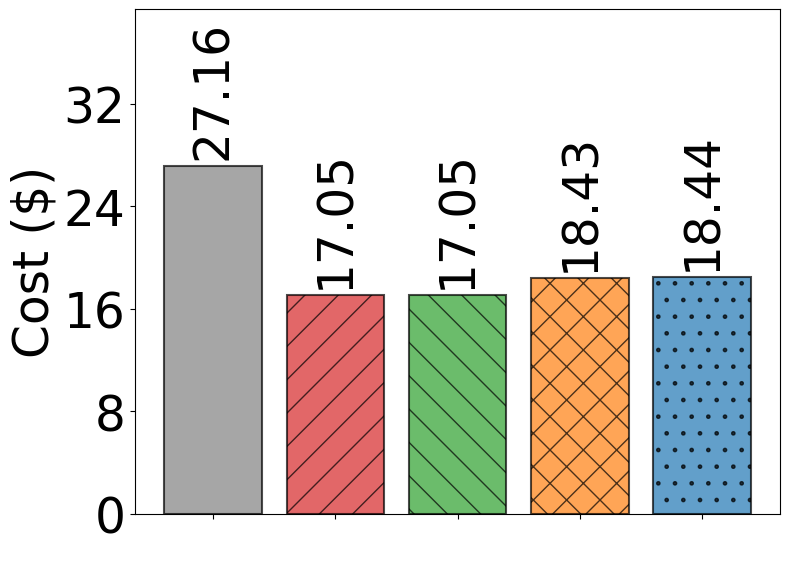

Saved: ./cost_comparison_scenario_A_llama3_70b.pdf
Offline Cost/Throughput (normalized, lower=cheaper):
  only_ondemand                        1.000  (baseline)
  no_handle                            0.925  (+7.5%)
  request_migration                    0.846  (+15.4%)
  concurrent_initialization            0.829  (+17.1%)
  shuntserve                           0.757  (+24.3%)

Online Avg Cost*Latency (normalized, lower=cheaper):
  only_ondemand                        1.000  (baseline)
  no_handle                            0.907  (+9.3%)
  request_migration                    0.874  (+12.6%)
  concurrent_initialization            0.778  (+22.2%)
  shuntserve                           0.725  (+27.5%)

Online P90 Cost*Latency (normalized, lower=cheaper):
  only_ondemand                        1.000  (baseline)
  no_handle                            1.025  (-2.5%)
  request_migration                    0.927  (+7.3%)
  concurrent_initialization            0.863  (+13.7%)
  shuntserve    

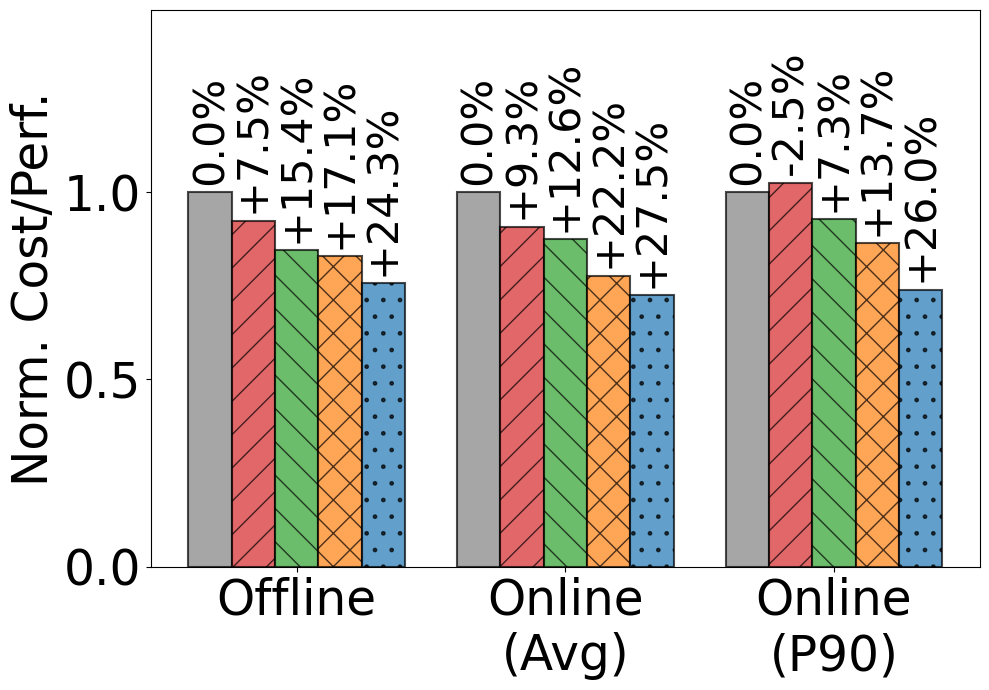

Saved: ./cost_efficiency_scenario_A_llama3_70b.pdf


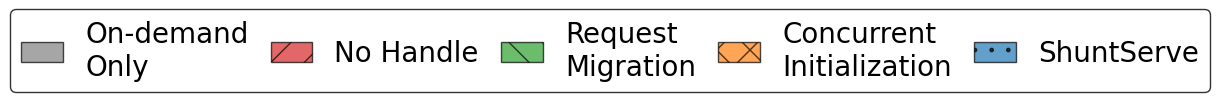

Saved: ./cost_legend_scenario_A_llama3_70b.pdf


In [9]:
run_analysis("llama3-70b")


  qwen3-32b — Scenario A — 50 min

[qwen3-32b] Node groups: {'on_demand_g5_12xlarge': 2, 'on_demand_g6e_xlarge': 4, 'spot_g5_12xlarge': 2, 'spot_g6_12xlarge': 3, 'spot_g6e_xlarge': 4}
[qwen3-32b] Initial state: {'g5.12xlarge': {'spot_active': 0, 'od_active': 2, 'spot_total': 2, 'od_total': 2}, 'g6.12xlarge': {'spot_active': 3, 'od_active': 0, 'spot_total': 3, 'od_total': 0}, 'g6e.xlarge': {'spot_active': 4, 'od_active': 0, 'spot_total': 4, 'od_total': 4}}


[qwen3-32b] Switching times: {'shuntserve': [104.2, 92.8, 101.21, 93.94, 101.18], 'concurrent_initialization': [97.03, 93.86, 102.77, 84.9, 96.85], 'request_migration': [91.65, 99.64, 95.53, 95.07, 96.21], 'no_handle': [94.44, 100.7, 86.93, 85.13, 86.52]}
[qwen3-32b] Offline throughputs: {'only_ondemand': '5.4607', 'shuntserve': '5.3667', 'concurrent_initialization': '5.1600', 'request_migration': '4.8963', 'no_handle': '4.7993'}
[qwen3-32b] Online mean latencies: {'only_ondemand': '133.56', 'shuntserve': '137.24', 'concurrent_initialization': '145.80', 'request_migration': '183.12', 'no_handle': '203.53'}
  Compound events: 5

Spot price mode: AVG
  only_ondemand                        $27.1607
  shuntserve                           $18.1727
  concurrent_initialization            $18.1461
  request_migration                    $17.0496
  no_handle                            $17.0496


,Approach,Spot Price Mode,Cost ($),Offline Throughput (req/s),Online Mean Latency (s)
0,only_ondemand,avg,27.1607,5.46,133.56
1,shuntserve,avg,18.1727,5.37,137.24
2,concurrent_initialization,avg,18.1461,5.16,145.80
3,request_migration,avg,17.0496,4.90,183.12
4,no_handle,avg,17.0496,4.80,203.53


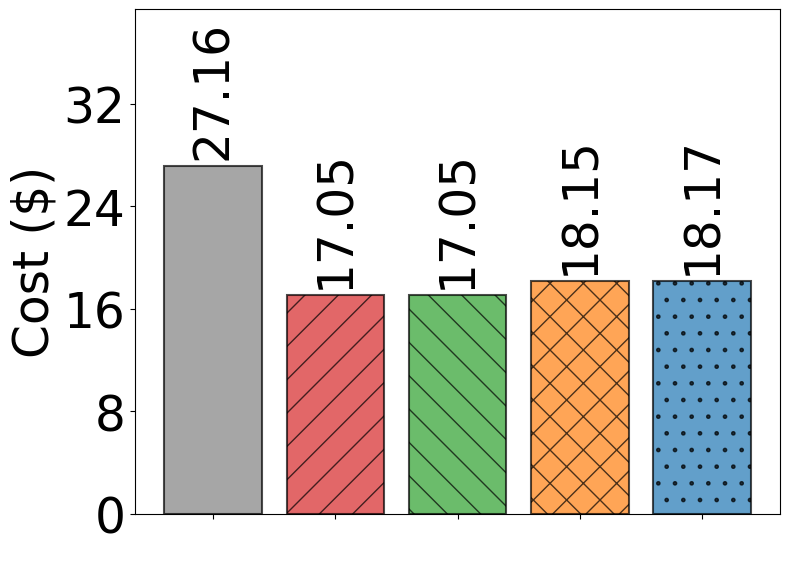

Saved: ./cost_comparison_scenario_A_qwen3_32b.pdf


Offline Cost/Throughput (normalized, lower=cheaper):
  only_ondemand                        1.000  (baseline)
  no_handle                            0.714  (+28.6%)
  request_migration                    0.700  (+30.0%)
  concurrent_initialization            0.707  (+29.3%)
  shuntserve                           0.681  (+31.9%)

Online Avg Cost*Latency (normalized, lower=cheaper):
  only_ondemand                        1.000  (baseline)
  no_handle                            0.957  (+4.3%)
  request_migration                    0.861  (+13.9%)
  concurrent_initialization            0.729  (+27.1%)
  shuntserve                           0.688  (+31.2%)

Online P90 Cost*Latency (normalized, lower=cheaper):
  only_ondemand                        1.000  (baseline)
  no_handle                            1.038  (-3.8%)
  request_migration                    0.997  (+0.3%)
  concurrent_initialization            0.811  (+18.9%)
  shuntserve                           0.704  (+29.6%)


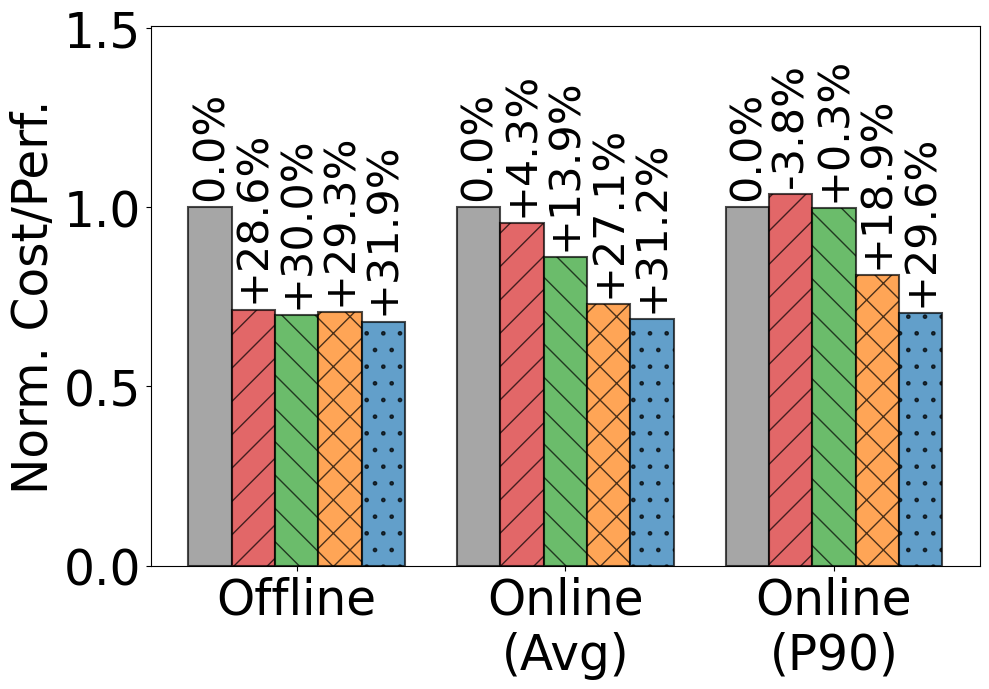

Saved: ./cost_efficiency_scenario_A_qwen3_32b.pdf


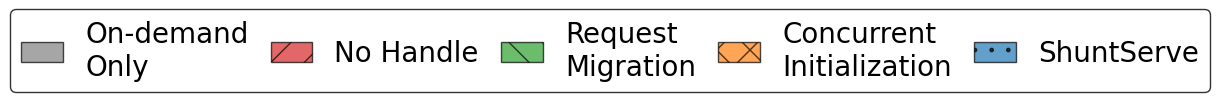

Saved: ./cost_legend_scenario_A_qwen3_32b.pdf


In [10]:
run_analysis("qwen3-32b")